# 05. 畳み込み・フィルタ・畳み込み定理

**学習目標**: **畳み込み**(周囲の値を混ぜる操作)と **フィルタ**(周波数ごとに残す/消す操作)を、
**畳み込み定理** で結びつける。平滑化とノイズ除去を実装する。

## Big Picture / Definition

畳み込み:

$$ (f * g)(t) = \int_{-\infty}^{\infty} f(\tau)\,g(t-\tau)\,d\tau. $$

**畳み込み定理**(本章の心臓部):

$$ \widehat{f * g} = \hat f \cdot \hat g. $$

「時間で畳み込む」=「周波数で掛ける」。だから **フィルタ = 周波数領域での掛け算** です。

## Intuition

- 畳み込み = カーネル $g$ で「ご近所の重み付き平均」を作る(ぼかし=平滑化)
- ローパス = 高周波を 0 倍、低周波を 1 倍する掛け算 = なめらかなカーネルでの畳み込み
- ハイパス/バンドパスも同様に「どの周波数を残すか」を選ぶだけ

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

## Computation 1 — 畳み込み定理を数値で確認

In [2]:
# Convolution in time == multiplication in frequency (circular convolution is exact).
rng = np.random.default_rng(0)
x = rng.standard_normal(64)
h = filters.gaussian_kernel(64, sigma=3.0)
lhs = np.fft.fft(filters.circular_convolve(x, h))
rhs = np.fft.fft(x) * np.fft.fft(h)
print("‖fft(x*h) - fft(x)·fft(h)‖ =", np.max(np.abs(lhs - rhs)))

‖fft(x*h) - fft(x)·fft(h)‖ = 3.66205343881779e-15


### 畳み込みは「反転してずらす」

各シフト $t_0$ で $f(\tau)$ と $g(t_0-\tau)$ の重なり(積の面積)が $(f*g)(t_0)$ になる。

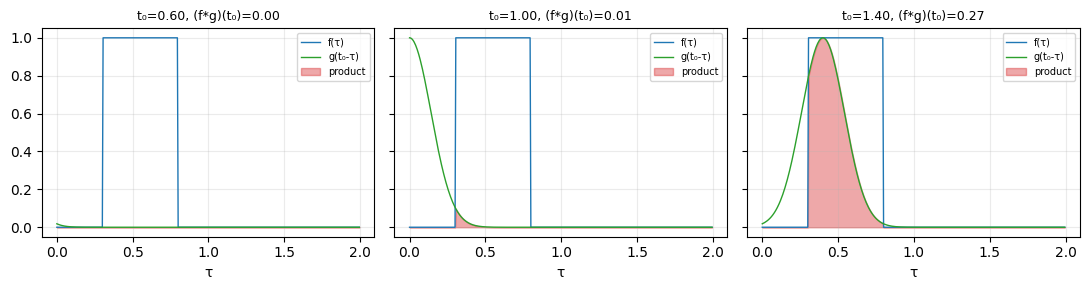

In [3]:
# Convolution as flip-and-slide: the shaded product area is (f*g)(t0).
t, _ = signals.time_grid(2.0, 200.0)
f = ((t > 0.3) & (t < 0.8)).astype(float)
g = np.exp(-((t - 1.0) ** 2) / (2 * 0.02))
plotting.plot_convolution_slide(t, f, g)
plt.show()

## Computation 2 — 平滑化(ガウス畳み込み)でノイズを抑える

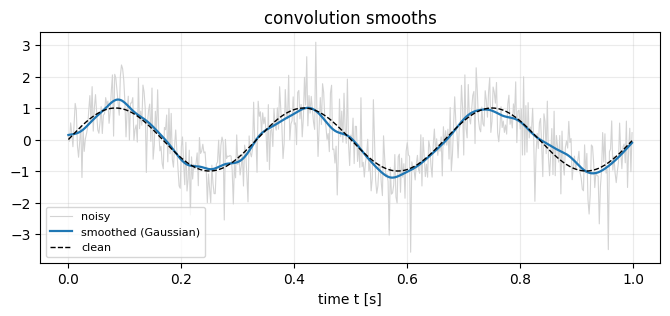

In [4]:
# Smoothing = convolution with a Gaussian kernel.
fs = 500.0
t, _ = signals.time_grid(1.0, fs)
clean = signals.sine(t, 3.0)
noisy = signals.add_noise(clean, snr_db=0.0, seed=0)
smooth = filters.smooth_gaussian(noisy, sigma=8.0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, noisy, color="lightgray", lw=.8, label="noisy")
ax.plot(t, smooth, color="#1f77b4", lw=1.6, label="smoothed (Gaussian)")
ax.plot(t, clean, color="black", lw=1, ls="--", label="clean")
ax.set_xlabel("time t [s]"); ax.set_title("convolution smooths"); ax.legend(fontsize=8)
ax.grid(alpha=.25)
plt.show()

## Computation 3 — ローパスフィルタでノイズ除去

周波数領域で高周波を切る = ノイズ(広帯域)を落とし、信号(低周波)を残す。

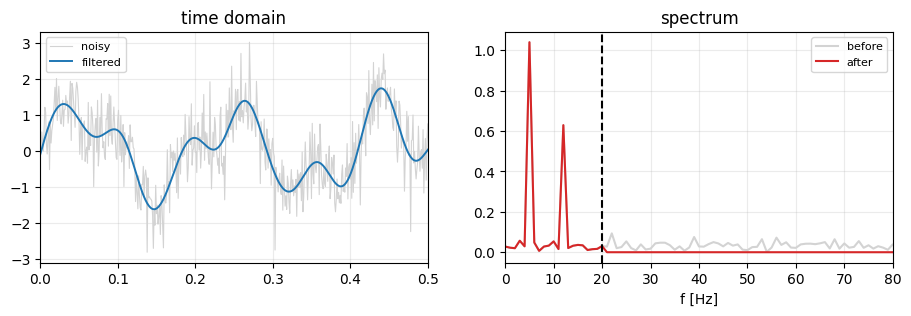

In [5]:
# Low-pass filtering in the frequency domain removes broadband noise.
fs = 1000.0
t, x = datasets.make_multitone(fs=fs, duration=1.0, freqs=(5, 12), amps=(1.0, .6), snr_db=3)
y = filters.lowpass(x, fs, cutoff=20.0)
f0, a_in = transforms.amplitude_spectrum(x, fs)
_, a_out = transforms.amplitude_spectrum(y, fs)

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(t, x, color="lightgray", lw=.8, label="noisy")
ax[0].plot(t, y, color="#1f77b4", lw=1.4, label="filtered")
ax[0].set_xlim(0, 0.5); ax[0].set_title("time domain"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.25)
ax[1].plot(f0, a_in, color="lightgray", label="before")
ax[1].plot(f0, a_out, color="#d62728", label="after")
ax[1].axvline(20, color="black", ls="--"); ax[1].set_xlim(0, 80)
ax[1].set_title("spectrum"); ax[1].set_xlabel("f [Hz]"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.25)
plt.show()

### ロー/バンド/ハイパスを一望

同じ信号(5 + 40 + 150 Hz)から、残す周波数帯を選ぶ操作。

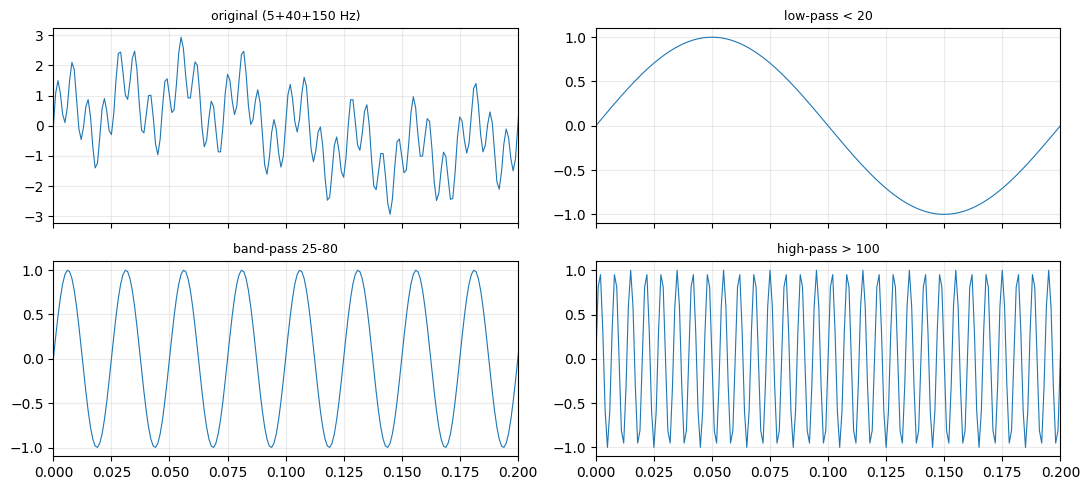

In [6]:
# Three ideal filters on the same 3-tone signal: keep low / mid / high bands.
fs = 1000.0
t, _ = signals.time_grid(1.0, fs)
x = signals.harmonic_sum(t, [5, 40, 150], [1.0, 1.0, 1.0])
lo = filters.lowpass(x, fs, 20)
bd = filters.bandpass(x, fs, 25, 80)
hi = filters.highpass(x, fs, 100)
fig, ax = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
for a_, sig, ttl in zip(ax.ravel(), [x, lo, bd, hi],
                        ["original (5+40+150 Hz)", "low-pass < 20", "band-pass 25-80", "high-pass > 100"],
                        strict=True):
    a_.plot(t, sig, lw=0.8); a_.set_title(ttl, fontsize=9); a_.set_xlim(0, 0.2); a_.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Application & TODO

応用: 画像のぼかし/輪郭抽出(09 章の 2D 版)、音声の帯域分割、移動平均(金融)、
微分方程式の Green 関数(畳み込みで解を表す)。

```{admonition} TODO(発展として追記予定)
:class: tip
- デルタ関数 δ(畳み込みの単位元)と超関数の入口を丁寧に
- Green 関数: 線形 PDE の解 = 入力 ∗ インパルス応答
- 理想フィルタ(ブリックウォール)の弊害(リンギング)と実用フィルタ(Butterworth 等)
- バンドパス/ハイパスでの特徴抽出デモ
```